In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02vvvm705' -- 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering Science, Jade Univer...",https://openalex.org/W4288057559
1,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Department...",https://openalex.org/W4288057559
2,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Automotive and Powe...",https://openalex.org/W4316659485
3,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Automotive and Power Electronics Jade Universi...,https://openalex.org/W4316659485
4,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Ofener St...",https://openalex.org/W4311937459


In [6]:
MAPPING_DICT = {
    'Fachbereich Seefahrt und Logistik': ['maritime', 'marine', 'seefahrt'],
    'Fachbereich Architektur': ['archite(k|c)tur', 'rural spaces'],
    'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie': ['geoinformat(ion|ics)', 
                                                                     'audiolog(ie|y)', 'civil', 
                                                                     'hearing technology', 'geoinformati(k|c)',
                                                                     'assistance systems', 'assistive',
                                                                     'acoustics', 'gesundheit',
                                                                     'architecture', 'pflegewissenschaft',
                                                                     'technology and health'],
    'Fachbereich Ingenieurwissenschaften': ['dep(.|t.|ar(t)?ment) (of|for) engineering', 'engineering department', 'ingenieurwissenschaften',
                                            'verfahrenstechnik', 'mechatronic systems', 'production and industrial'
                                           ],
    'Fachbereich Management': ['management, information(,| and) technolog(ie|y)'],
    'Fachbereich Wirtschaft': ['wirtschaft und gesellschaft']
}

In [7]:
with open('./mapping_tables_fak/jade.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [8]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [9]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [10]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering Science, Jade Univer...",https://openalex.org/W4288057559
1,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Department...",https://openalex.org/W4288057559
2,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Automotive and Powe...",https://openalex.org/W4316659485
3,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Automotive and Power Electronics Jade Universi...,https://openalex.org/W4316659485
4,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Ofener St...",https://openalex.org/W4311937459
...,...,...,...,...
531,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Germany",https://openalex.org/W4386493148
532,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Institute for Community Medicine, University M...",https://openalex.org/W4381094122
533,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade Hochschule, Wilhelmshaven, Germany",https://openalex.org/W3044865449
534,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Friedrich...",https://openalex.org/W3134388035


In [11]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Jade University of Applied Sciences, Ofener Str. 16/19, 26129 Oldenburg, Germany',
       'Jade University of Applied Sciences, Friedrich-Paffrath-Strae 101, 26389 Wilhelmshaven, Germany',
       'Jade University of Applied Sciences Oldenburg, TGM , Oldenburg, Germany',
       'Jade University of Applied Sciences, Wilhelmshaven, Germany',
       'Jade University of Applied Sciences Friedrich-Paffrath-Straße 101, Wilhelmshaven, Germany',
       'Jade University of Applied Sciences Friedrich-Paffrath-Strae 101, Wilhelmshaven, Germany',
       'Jade University of Applied Science, Wilhelmshaven, Germany, --- Select a Country ---',
       'Jade University of Applied Sciences, Oldenburg, Germany',
       'a Department for Research and Knowledge Transfer, Jade University of Applied Sciences, Ofener Straße 16/19, Oldenburg, Germany',
       'ResearchFonds of the University of Applied Sciences Oldenburg, Wilhelmshaven, Elsfleth',
       'Jade University of applied science, Germany',
   

In [12]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fachbereich Architektur,20
1,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",196
2,Fachbereich Ingenieurwissenschaften,104
3,Fachbereich Management,14
4,Fachbereich Seefahrt und Logistik,18
5,Fachbereich Wirtschaft,2
6,NaN,182


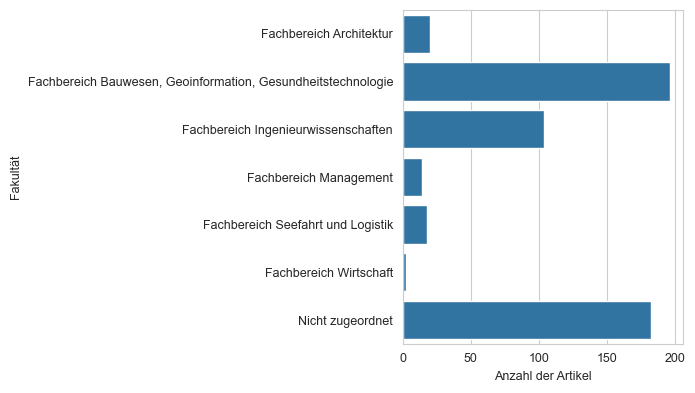

In [13]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [14]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6604477611940298

In [15]:
MAPPING_DICT_DEPT = {
    'Fachbereich Seefahrt und Logistik': {},
    'Fachbereich Architektur': {
        #'Institut für Architektur und Städtebau Oldenburg (IASO)': [],
        #'Institut für Baumanagement (IBM)': [],
        #'Institut für Intermediale Gestaltung und Darstellung (IGD)': [],
        #'Institut für nachhaltige Architektur und Umweltplanung (INAU)': [],
    },
    'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie': {
        'Institut für Hörtechnik und Audiologie': ['hearing technology', 'acoustics', 'audiolog(ie|y)'],
        'Institut für Technische Assistenzsysteme (ITAS)': ['technical (assistance|assistive)', 'assistive technologies'],
        #'Public Health M.Sc.': [],
        'Studiengang Angewandte Pflegewissenschaft': ['pflegewissenschaft'],
        'Studiengang Logopädie': ['logopädie'],
        'IAPG Institut für Angewandte Photogrammetrie und Geoinformatik (Standort Oldenburg)': ['photogramm(m)?etr(ie|y)'],
        'Institut für Mess- und Auswertetechnik (IMA)': ['auswertetechnik'],
        'Bauchemisches Labor': ['bauchemisches labor'],
        'Baustoffprüflabor - Institut für Materialprüfung': ['materialprüfung'],
    },
    'Fachbereich Ingenieurwissenschaften': {
        #'Fachgebiet Informationstechnologie im Maschinenbau': [],
        #'Institut für C-Techniken (ICT)': [],
        'Institut für Energie-, Verfahrens- und Umwelttechnik (EVU)': ['verfahrenstechnik'],
        #'Institut für Konstruktions- und Produktionstechnik (IKP)': [],
        #'Institut für nachhaltige Energieversorgung (InEv)': [],
        #'Studiengang Elektrotechnik (Bachelor)': [],
    },
    'Fachbereich Management, Information, Technologie (MIT)': {
        #'Institut für Medienwirtschaft und Journalismus (InMWJ)': [],
        #'Institut für Wirtschaftsinformatik (IfW)': [],
    },
    'Fachbereich Wirtschaft und Gesellschaft': {}
}

In [16]:
with open('./mapping_tables_dept/jade.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [17]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [18]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fachbereich Ingenieurwissenschaften')

In [19]:
df_with_inst[(df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['Department of Engineering Science, Jade University of Applied Sciences, Wilhelmshaven, Germany',
       'Jade University of Applied Sciences,Department of Engineering Science,Wilhelmshaven,Germany',
       'Department of Engineering, Automotive and Power Electronics Jade University of Applied Sciences, Wilhelmshaven, Germany',
       'Automotive and Power Electronics Jade University of Applied Sciences,Department of Engineering,Wilhelmshaven,Germany',
       'Fachbereich Ingenieurwissenschaften, Jade Hochschule, Friedrich-Paffrath-Straße\xa0101, 26389, Wilhelmshaven, Deutschland',
       'Institute for Production and Industrial Service Management, Jade University, Friedrich-Paffrath-Str.\xa0101, 26389 Wilhelmshaven, Germany',
       'Institute for Production and Industrial Service Management, Jade University, Friedrich-Paffrath-Str.\xa0101, 26389, Wilhelmshaven, Germany',
       'Jade University of Applied Sciences,Department of Engineering,Wilhelmshaven,Germany',
       'Depar

In [20]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,"Institut für Energie-, Verfahrens- und Umweltt...",2
1,NaN,102


In [21]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
0,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering Science, Jade Univer...",https://openalex.org/W4288057559,None
1,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Department...",https://openalex.org/W4288057559,None
2,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Automotive and Powe...",https://openalex.org/W4316659485,None
3,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Automotive and Power Electronics Jade Universi...,https://openalex.org/W4316659485,None
5,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Fachbereich Ingenieurwissenschaften, Jade Hoch...",https://openalex.org/W4281609022,None
...,...,...,...,...,...
507,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Jade University of ...",https://openalex.org/W4388565357,None
512,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Friedrich-Paffrath-...",https://openalex.org/W3046399132,None
520,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Jade University of ...",https://openalex.org/W2999672906,None
526,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Departmen...",https://openalex.org/W3117662728,None


In [22]:
MAPPING_DICT_INST = {}

In [23]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/jade.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)